In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, NodeRFModel, NodeLSTMModel, GATv2Model, ClimateologyModel, SpatialGNNModel
from src.evaluation import Evaluator

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1


config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    include_gisd        = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )       
data_orchestrator = DataOrchestrator(config).build()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23203755/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [2]:
n_epochs        = 25
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

shallowdata        = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
graphdataloader_1  = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
# graphdataloader_2  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('mesh_graph').construct_dataloaders()
# graphdataloader_3  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('geographical_neighbors1').construct_dataloaders()
# graphdataloader_4  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity1').construct_dataloaders()
# graphdataloader_5  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity2').construct_dataloaders()
# graphdataloader_6  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity3').construct_dataloaders()
# graphdataloader_7  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity4').construct_dataloaders()
# graphdataloader_8  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity5').construct_dataloaders()
# graphdataloader_9  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter14_1').construct_dataloaders()
# graphdataloader_10 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter14_2').construct_dataloaders()
# graphdataloader_11 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter14_3').construct_dataloaders()
# graphdataloader_12 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter14_4').construct_dataloaders()
# graphdataloader_13 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter24_1').construct_dataloaders()
# graphdataloader_14 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter24_2').construct_dataloaders()
# graphdataloader_15 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter24_3').construct_dataloaders()
# graphdataloader_16 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter24_4').construct_dataloaders()

In [3]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

climateology = ClimateologyModel(shallowdata)
climateology.forecast('test')

ClimateologyModel(name='climateology_model')

## RF

In [5]:
rf = NodeRFModel(shallowdata)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=100)
rf.train()
rf.forecast('test')

NodeRFModel(name='noderfmodel')

## LSTM


==                     lstm                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.6447, val loss: 0.9543 ✓ (new best)
Epoch 11 train loss: 0.5380, val loss: 0.6312 ✓ (new best)
Epoch 21 train loss: 0.4694, val loss: 0.5153 ✓ (new best)
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 454.58it/s]

Test loss: 1.0203
forecasted ✓


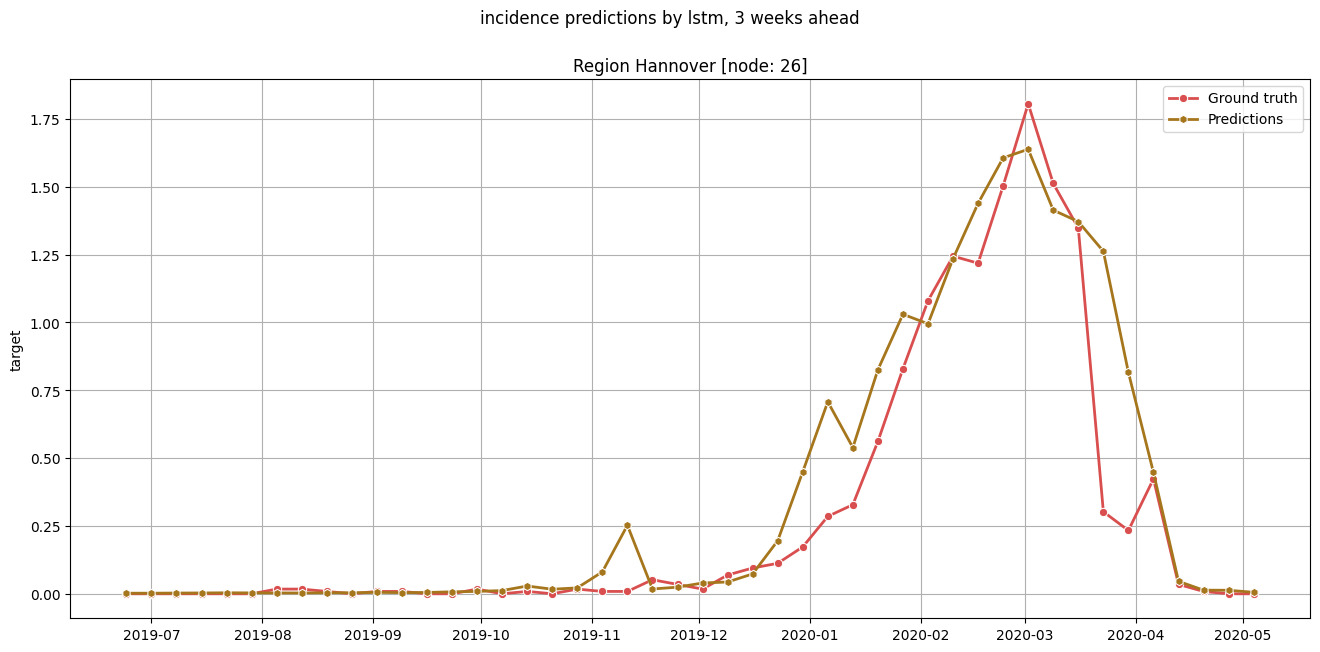

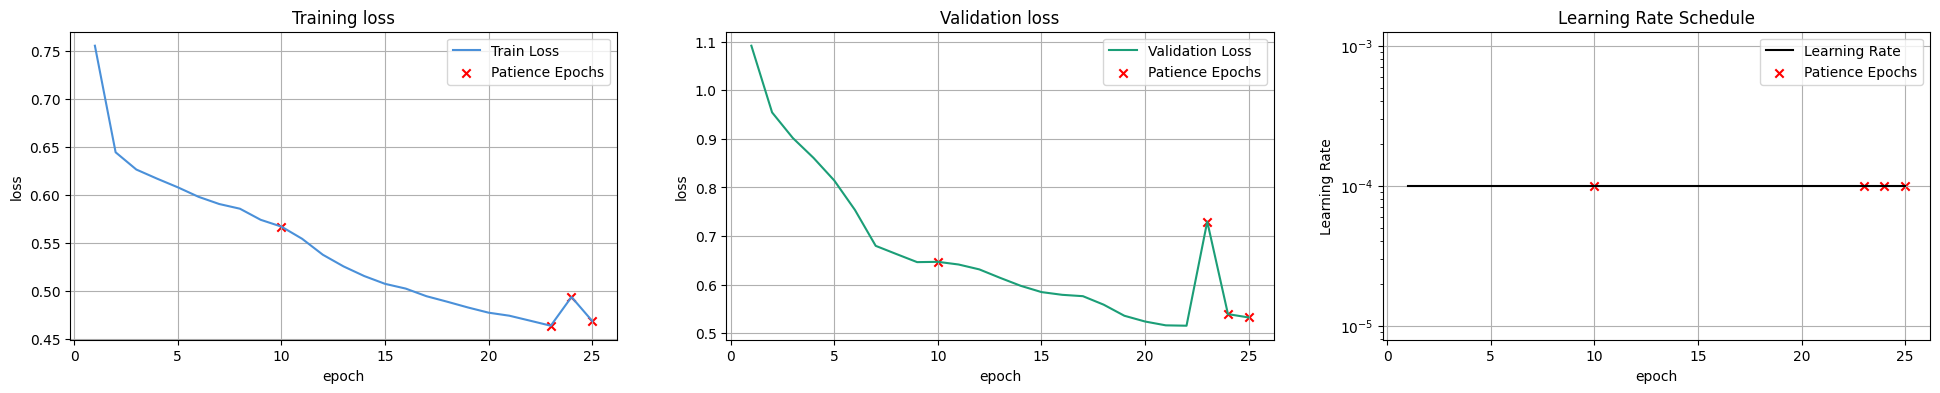

In [8]:
lstm = NodeLSTMModel(graphdataloader_1, name = 'lstm', verbose = 2)
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26)

## GNNs

In [7]:
# spatial_model1 = SpatialGNNModel(graphdataloader_id, name = 'gcn-identity_graph')
# spatial_model1.set_model_hparams()
# spatial_model1.set_global_hparams(**global_hparams)
# spatial_model1.train(verbose = 0, show_loss=False)
# spatial_model1.forecast('test')
# spatial_model1.show_forecasts(26)

# spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'gcn-boolean_neighbors')
# spatial_model2.set_model_hparams()
# spatial_model2.set_global_hparams(**global_hparams)
# spatial_model2.train(verbose = 0, show_loss=False)
# spatial_model2.forecast('test')
# spatial_model2.show_forecasts(26)


st1 = GATv2Model(graphdataloader_1, name = 'undertrained_gatv2')
st1.set_model_hparams()
st1.set_global_hparams(**global_hparams)
st1.train()
st1.forecast('test')
st1.show_forecasts(26)

# st2 = GATv2Model(graphdataloader_2, name = 'gatv2-2')
# st2.set_model_hparams()
# st2.set_global_hparams(**global_hparams)
# st2.train(verbose = 0, show_loss=False)
# st2.forecast('test')
# st2.show_forecasts(26)

# st3 = GATv2Model(graphdataloader_3, name = 'gatv2-3')
# st3.set_model_hparams()
# st3.set_global_hparams(**global_hparams)
# st3.train(verbose = 0, show_loss=False)
# st3.forecast('test')
# st3.show_forecasts(26)


# st4 = GATv2Model(graphdataloader_10, name = 'gatv2-10')
# st4.set_model_hparams()
# st4.set_global_hparams(**global_hparams)
# st4.train(verbose = 0, show_loss=False)
# st4.forecast('test')
# st4.show_forecasts(26)


# st5 = GATv2Model(graphdataloader_14, name = 'gatv2-14')
# st5.set_model_hparams()
# st5.set_global_hparams(**global_hparams)
# st5.train(verbose = 0, show_loss=False)
# st5.forecast('test')
# st5.show_forecasts(26)



<Fig(legend, ticks, labels)>

In [9]:
model = GATv2Model.load('saved_models/my_trained_model.pt')
model.forecast('test')

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/modelmanager.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  save_dict = torch.load(filepath, map

✓ Model loaded: saved_models/my_trained_model.pt


GATv2Model(name='undertrained_gatv2')

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

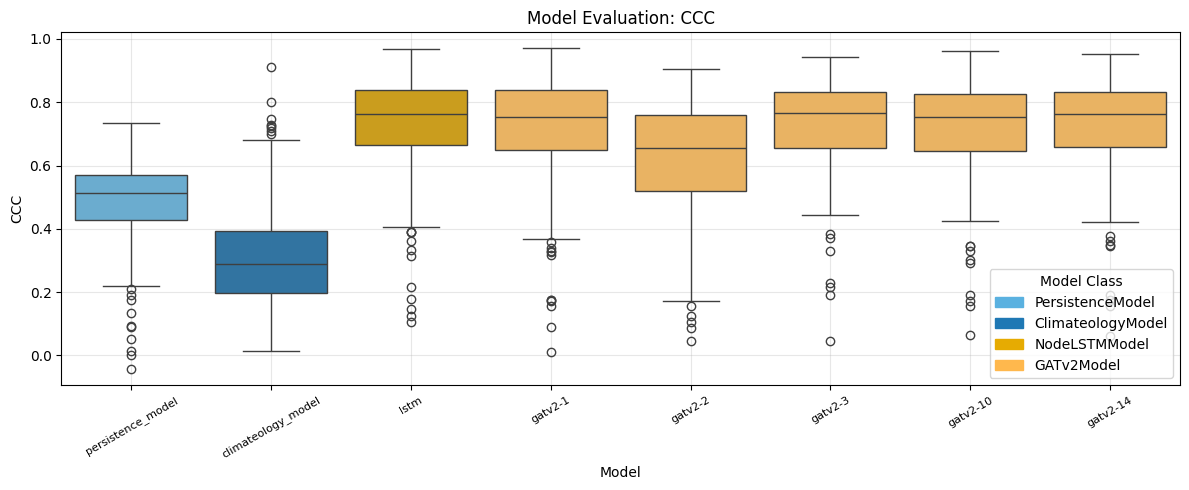

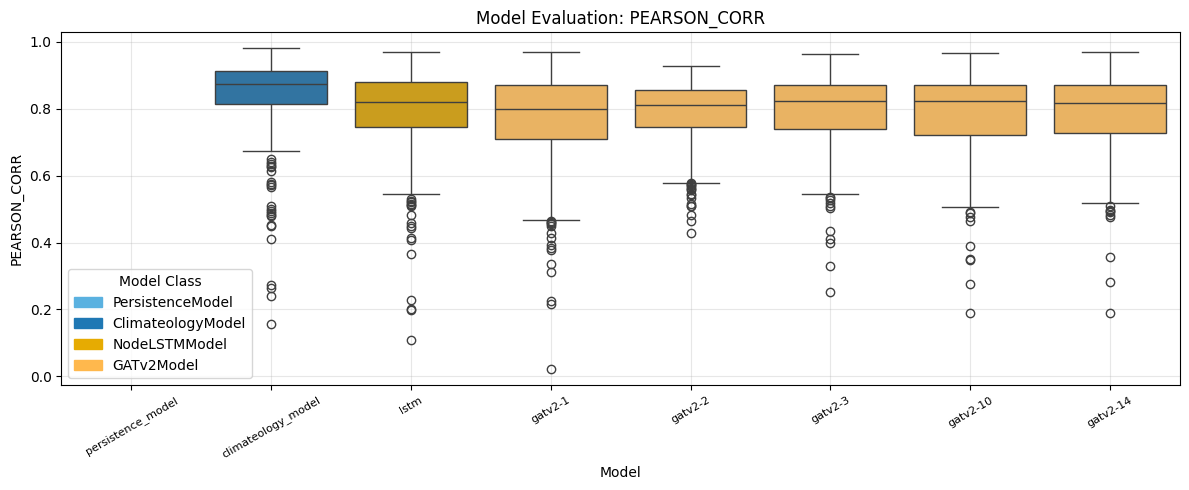

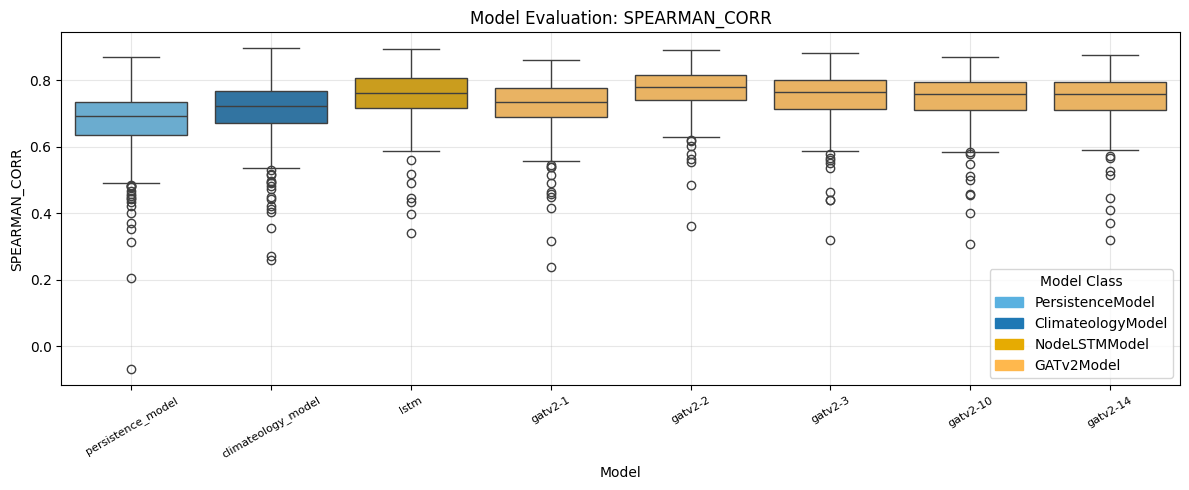

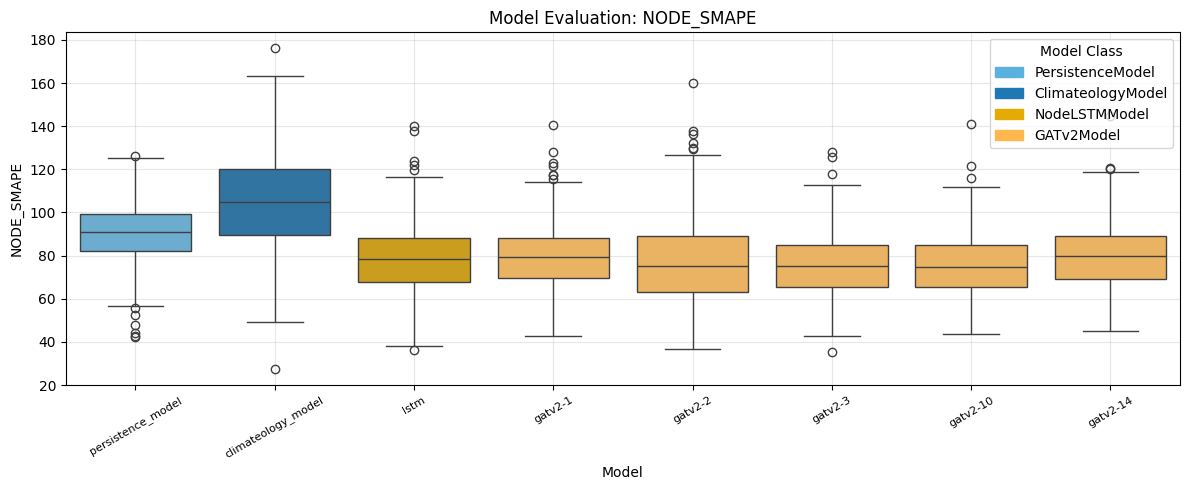

In [12]:
evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('pearson_corr', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('spearman_corr', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('node_smape', horizon = 'horizon_0', plot_type='box')